In [70]:
from dynrdpg import DynamicRDPG
from dynrdpg.datasets import simulate_network_rw, simulate_network_gp

0.09631200000000001


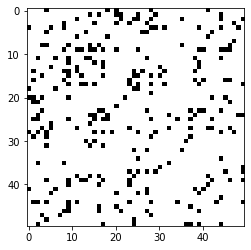

In [89]:
Y, X, probas_true = simulate_network_gp(
    n_nodes=50, n_time_steps=100, density=0.1, random_state=32, length_scale=3)

print(np.mean([Yt.mean() for Yt in Y]))

plt.imshow(Y[-1].toarray(), cmap='gray_r')

0.19834400000000002


/Users/joshua/myworkspace/dynrdpg/dynrdpg/datasets/synthetic.py:39: RuntimeWarning: invalid value encountered in divide
  X[t] = np.where(norms > 1, X[t] / norms, X[t])


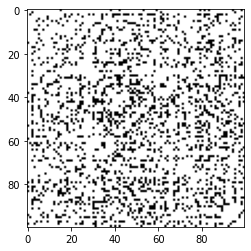

In [3]:
Y, X, probas_true = simulate_network_rw(
    n_nodes=100, n_time_steps=100, density=0.2, random_state=12)

print(np.mean([Yt.mean() for Yt in Y]))

plt.imshow(Y[-1].toarray(), cmap='gray_r')

In [90]:
import os

out_dir = f'fase_data/'
if not os.path.exists(out_dir):
    os.makedirs(out_dir)

np.savetxt(os.path.join(out_dir, 'time_points.npy'), np.linspace(0, 1, len(Y)))
for t in range(len(Y)):
    np.savetxt(os.path.join(out_dir, f'Y_{t+1}.npy'), Y[t].toarray())
    np.savetxt(os.path.join(out_dir, f'X_{t+1}.npy'), X[t])

In [91]:
! Rscript fase.R

Type 'citation("pROC")' for a citation.

Attaching package: ‘pROC’

The following objects are masked from ‘package:stats’:

    cov, smooth, var


── Column specification ────────────────────────────────────────────────────────
cols(
  X1 = col_double()
)

[1] "q = 4 ngcv = -1.2330893760886"
[1] "q = 6 ngcv = -1.23349739523157"
[1] "q = 8 ngcv = -1.23304078556176"
[1] "q = 10 ngcv = -1.23202999174261"
[1] "q = 12 ngcv = -1.23098622402426"
[1] "q = 14 ngcv = -1.23005964995991"
[1] "q = 16 ngcv = -1.22923884741596"
[1] "q = 18 ngcv = -1.22856389601978"
[1] "q = 20 ngcv = -1.22781704308384"
[1] "q = 22 ngcv = -1.22715306537115"
[1] "q = 24 ngcv = -1.22658302057001"
[1] 0.004017765


In [94]:
rdpg = DynamicRDPG(n_features=2, rw_order=2)
rdpg.sample(Y, n_burnin=1000, n_samples=1000)

100%|██████████████████████████████████████████████████████████████████████████████| 2000/2000 [04:13<00:00,  7.90it/s]


In [95]:
from scipy.linalg import orthogonal_procrustes

X_pred = rdpg.X_.copy()
for t in range(len(Y)):
    R, _ = orthogonal_procrustes(X_pred[t], X[t])
    X_pred[t] = X_pred[t] @ R
    
#print(rdpg.auc_)
np.mean((X_pred - X) ** 2)

0.002196329182692504